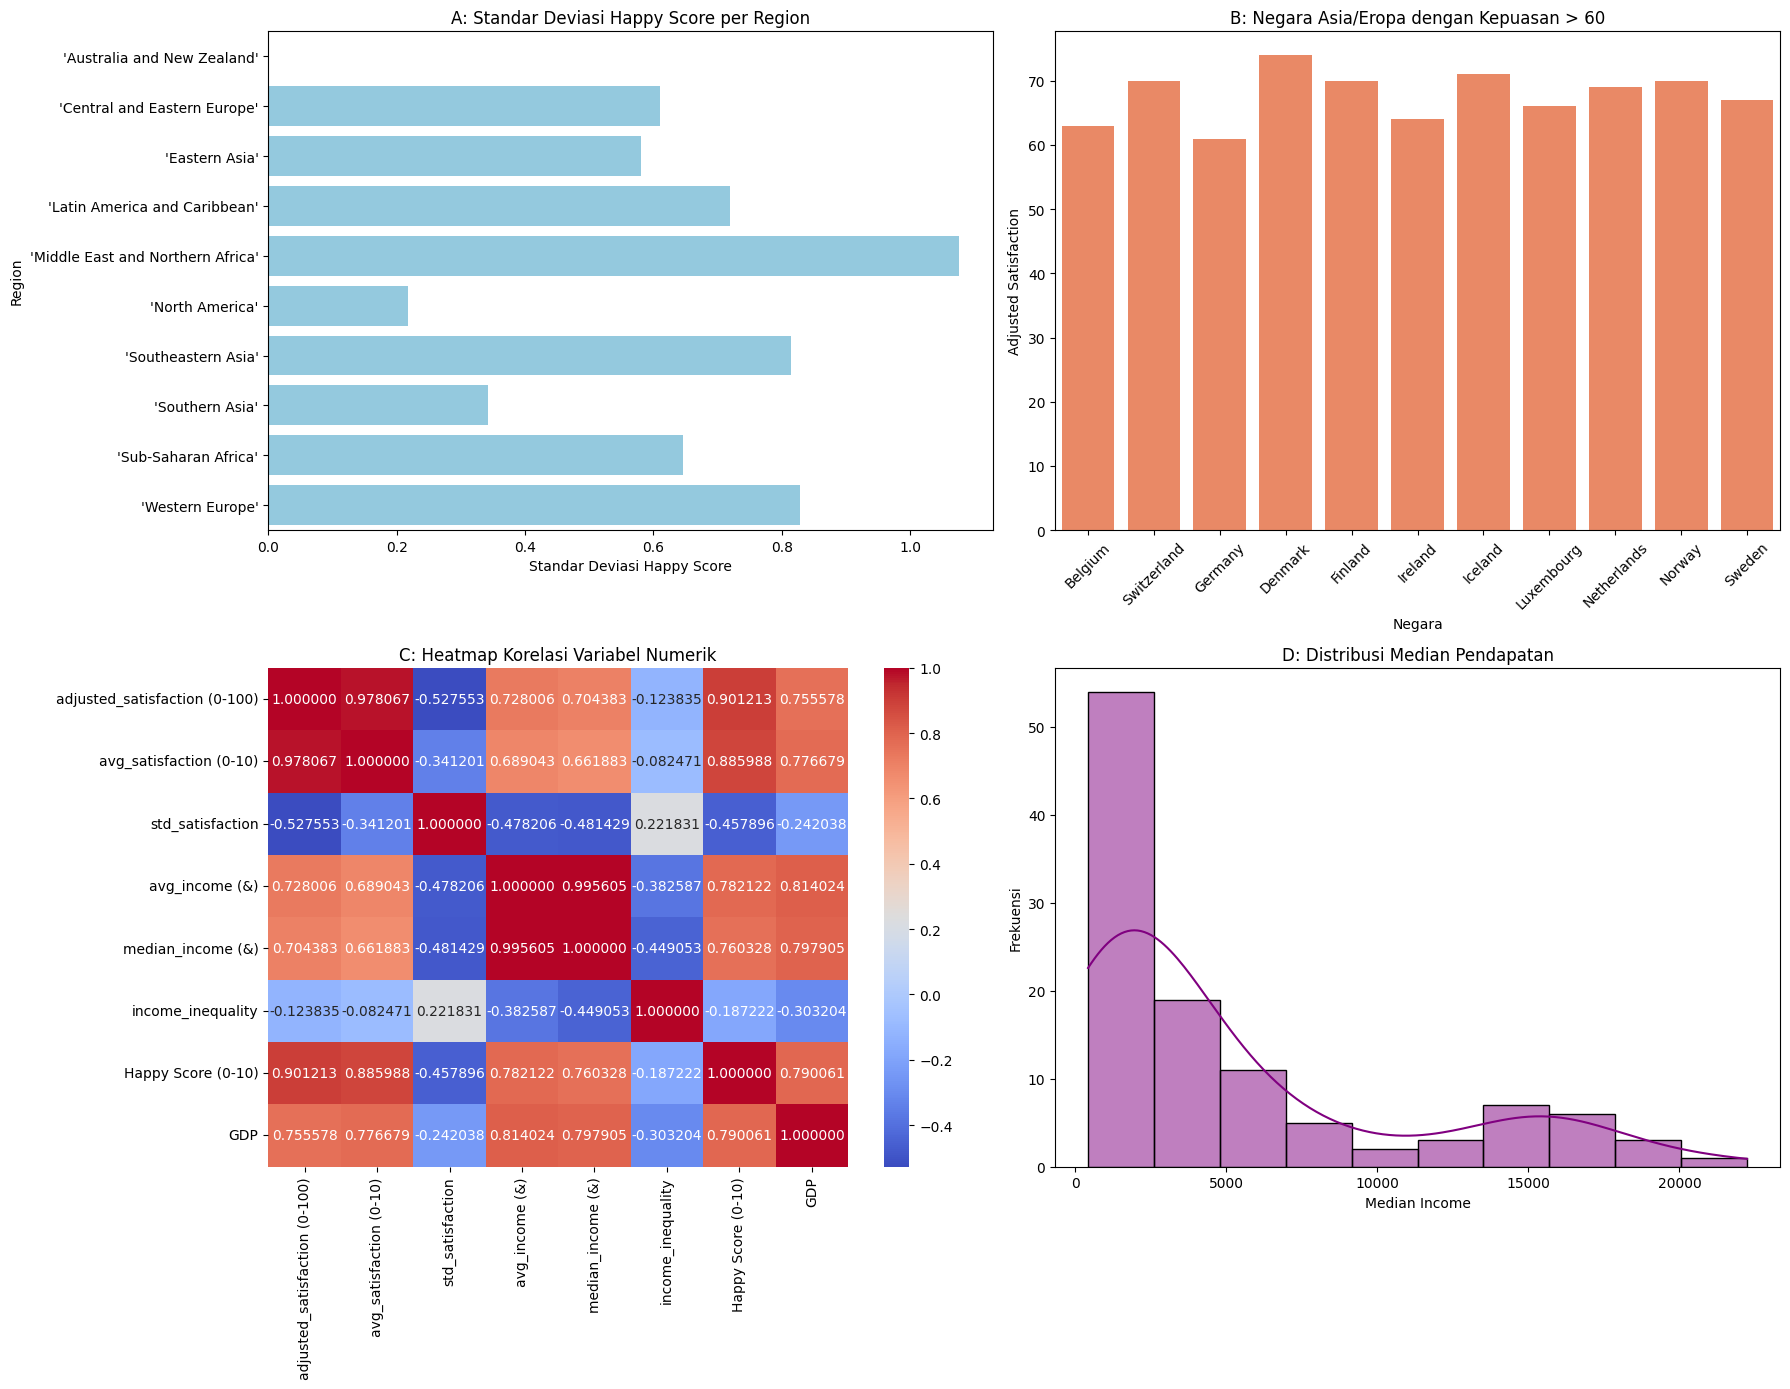

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Kelas D_Happiness and Satisfaction.csv', sep=';', decimal=',')

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# GRAFIK 1: Kategori A (Agregasi)
# Menghitung standar deviasi tanpa pembulatan angka
agg_df = df.groupby('Region')['Happy Score (0-10)'].std().reset_index()
sns.barplot(data=agg_df, x='Happy Score (0-10)', y='Region', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('A: Standar Deviasi Happy Score per Region')
axes[0, 0].set_xlabel('Standar Deviasi Happy Score')
axes[0, 0].set_ylabel('Region')

# GRAFIK 2: Kategori B (Tren/Filter)
# Memfilter region yang mengandung kata 'Asia' atau 'Europe' dan skor > 60
region_filter = df['Region'].str.contains('Asia|Europe', case=False, na=False)
satisfaction_filter = df['adjusted_satisfaction (0-100)'] > 60
filter_df = df[region_filter & satisfaction_filter]

sns.barplot(data=filter_df, x='Country', y='adjusted_satisfaction (0-100)', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('B: Negara Asia/Eropa dengan Kepuasan > 60')
axes[0, 1].set_xlabel('Negara')
axes[0, 1].set_ylabel('Adjusted Satisfaction')
axes[0, 1].tick_params(axis='x', rotation=45) # Memutar label X agar nama negara terbaca

# GRAFIK 3: Kategori C (Korelasi)
# Mengambil hanya kolom numerik untuk korelasi tanpa pembulatan angka
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=axes[1, 0], fmt='.6f')
# fmt='.6f' digunakan agar angka di dalam heatmap ditampilkan spesifik tanpa pembulatan berlebih
axes[1, 0].set_title('C: Heatmap Korelasi Variabel Numerik')

# GRAFIK 4: Kategori D (Distribusi)
sns.histplot(data=df, x='median_income (&)', kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('D: Distribusi Median Pendapatan')
axes[1, 1].set_xlabel('Median Income')
axes[1, 1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()